# Projet Machine Learning — Prédiction des cartons jaunes
### FIFA World Cup 2026 — Player Performance Dataset

**Auteur :** Kiritheepan Robinsan — ENSEA · Barcelona Summer Course 2026  
**Variable cible :** `yellow_cards` (le joueur a-t-il reçu un carton jaune : 0 = non, 1 = oui)

---

## Objectif et démarche

Ce projet suit les consignes en trois parties :

1. **Apprentissage supervisé** — entraîner et comparer un Arbre de décision, une Forêt aléatoire et un Gradient Boosting, réglés par `GridSearchCV`, puis interpréter précision / rappel / faux positifs / faux négatifs.
2. **Importance des variables** — importance native, importance par permutation, puis SHAP (summary + waterfall).
3. **Apprentissage non supervisé** — réduction de dimension (PCA) et clustering (KMeans, DBSCAN).

## Pourquoi cette variable cible ?

`yellow_cards` est **déséquilibrée** (~90 % de 0, ~10 % de 1). Ce choix est volontaire : il oblige à raisonner en **précision / rappel / F1** plutôt qu'en simple *accuracy*, car un modèle qui prédirait toujours « pas de carton » atteindrait déjà ~90 % d'accuracy sans rien apprendre. C'est le fil rouge pédagogique de tout le projet.

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100) #Sa permet d'afficher toutes les colonnes du DataFrame


In [6]:
df = pd.read_csv("../Data/fifa_world_cup_2026_player_performance.csv")

## Partie 0 — Exploration et préparation des données

On commence par vérifier la forme du jeu de données, le type des colonnes et l'absence de valeurs manquantes.
Le dataset compte **54 600 lignes × 75 colonnes**, sans valeur manquante. Chaque joueur (`player_id`) apparaît environ 44 fois (une ligne par match) — ce point sera déterminant pour le découpage train/test.

In [ ]:
df.shape #verifeir le nombre de lignes et de colonnes du DataFrame

(54600, 75)

In [8]:
df.info() #verifier le type de chaque colonne et le nombre de valeurs non nulles

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [10]:
df.describe() #verifier les statistiques descriptives des colonnes numériques du DataFrame
#ici je vais chercher si il y a des valeurs qui n'ont aucun sens physique 

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,0.447051,0.048425,0.016112,0.017742,0.471832,15.470092,19.177308,0.808440,0.600293,0.162949,0.447784,0.018535,0.802656,0.627271,0.808681,0.226612,0.745256,0.362985,1.388571,2.465220,0.416886,0.323223,0.097912,0.005604,0.086905,0.121282,0.026274,0.026245,0.009176,0.048645,0.003333,3.996504,0.462372,18.645636,10.036502,8.849011,81.893535,3.634700,36.828995,44.716636,52.733712,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,0.947155,0.244501,0.074648,0.074896,0.936476,18.747632,22.623857,0.074286,1.154876,0.497236,0.863716,0.137432,1.343731,1.125812,1.534296,0.558672,1.171042,0.713418,2.017851,3.643392,0.771273,0.653396,0.297198,0.074653,0.316943,0.701090,0.135945,0.207966,0.095351,0.330748,0.057639,4.023194,0.475044,16.016266,10.581358,9.390937,10.771734,3.155846,31.072667,24.870780,23.903033,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,1.000000,5.000000,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.600000,0.000000,0.700000,25.675000,33.100000,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000


### Détection des valeurs aberrantes

Plutôt que de lire les 61 colonnes numériques une par une, on **trie par la valeur minimale** et on **filtre les colonnes ayant une valeur négative** : c'est la façon la plus rapide de repérer une valeur physiquement impossible (âge négatif, sentinelle du type `-200`, etc.). Ici, aucune anomalie — le jeu de données est propre.

In [11]:
df.describe().T.sort_values("min") # permet de trier les colonnes par la valeur minimale pour voir si il y a des valeurs qui n'ont aucun sens physique

,count,mean,std,min,25%,50%,75%,max
goals_opponent,54600.0,1.330476e+00,1.147814e+00,0.0,0.0,1.0,2.0,7.000000e+00
minutes_played,54600.0,3.619982e+01,3.641975e+01,0.0,0.0,24.0,75.0,9.000000e+01
goals_team,54600.0,1.330476e+00,1.147814e+00,0.0,0.0,1.0,2.0,7.000000e+00
expected_goals_xg,54600.0,1.611190e-02,7.464788e-02,0.0,0.0,0.0,0.0,2.310000e+00
shots_on_target,54600.0,4.842491e-02,2.445008e-01,0.0,0.0,0.0,0.0,5.000000e+00
...,...,...,...,...,...,...,...,...
consistency_score,54600.0,6.375040e+01,1.986003e+01,25.0,46.5,61.1,78.9,9.900000e+01
stamina_score,54600.0,8.189353e+01,1.077173e+01,50.0,74.6,82.6,90.0,9.900000e+01
weight_kg,54600.0,7.575485e+01,3.951481e+00,65.0,73.0,76.0,78.0,8.700000e+01
height_cm,54600.0,1.816543e+02,6.277792e+00,163.0,177.0,182.0,186.0,2.000000e+02


In [ ]:
desc = df.describe().T
desc[desc["min"] < 0]
# permet de voir directement les valeur negatives dans les colonnes numériques du DataFrame, 
#desc affiche uniquement les valeur True ou min est inferieur a 0

,count,mean,std,min,25%,50%,75%,max


In [ ]:
df.columns.tolist() # permet de voir la liste des colonnes du DataFrame

['player_id',
 'player_name',
 'age',
 'nationality',
 'team',
 'jersey_number',
 'position',
 'height_cm',
 'weight_kg',
 'preferred_foot',
 'club_name',
 'market_value_eur',
 'match_id',
 'match_date',
 'stadium',
 'city',
 'opponent_team',
 'tournament_stage',
 'match_result',
 'goals_team',
 'goals_opponent',
 'minutes_played',
 'goals',
 'assists',
 'shots',
 'shots_on_target',
 'expected_goals_xg',
 'expected_assists_xa',
 'key_passes',
 'successful_passes',
 'total_passes',
 'pass_accuracy',
 'dribbles_attempted',
 'successful_dribbles',
 'crosses',
 'successful_crosses',
 'tackles',
 'interceptions',
 'clearances',
 'blocks',
 'aerial_duels_won',
 'aerial_duels_lost',
 'recoveries',
 'defensive_actions',
 'fouls_committed',
 'fouls_suffered',
 'yellow_cards',
 'red_cards',
 'offsides',
 'saves',
 'save_percentage',
 'punches',
 'clean_sheet',
 'goals_conceded',
 'penalty_saves',
 'distance_covered_km',
 'sprint_distance_km',
 'top_speed_kmh',
 'accelerations',
 'decelerations',

In [15]:
#ici sa permet de voir les colonnes et surtout analyser quel colonne garder ou non pour l'analyse 
#notre but ici, on cherche a predire le nombre de cartons jaunes que les joueurs vont recevoir
#donc on va chercher les colonnes qui pourrais avoir un impact sur le nombre de cartons jaunes
#j'ai pris la cartons jaune car c'est resultat qui n'est pas evident 


### Corrélation des variables avec la cible

On calcule la corrélation linéaire de chaque variable numérique avec `yellow_cards`, triée par ordre décroissant.

**Résultat marquant :** aucune variable ne dépasse ~0,04 en valeur absolue. Autrement dit, **aucun lien linéaire simple** n'existe entre les statistiques disponibles et les cartons. Ce n'est pas une erreur : cela annonce que le problème est difficile, et justifie l'emploi de modèles capables de capter des **combinaisons** de variables (arbres, forêts, boosting) que la corrélation seule ne voit pas.

In [ ]:
df.corr(numeric_only=True)["yellow_cards"].sort_values(ascending=False)
#df.corr(numeric_only=True) permet de calculer la correlation entre les colonnes numériques du DataFrame
#correlation est un chiffre entre -1 et 1 qui indique la force de la relation entre deux variables, oauis
#proche de 1 signifie une forte correlation positive, proche de -1 signifie une forte correlation negative, et proche de 0 signifie aucune correlation
#numeric_only=True permet de ne prendre en compte que les colonnes numériques du DataFrame

#sort_values() permet de trier les valeurs de la correlation entre les colonnes numériques du DataFrame et la colonne "yellow_cards" par ordre croissant ou decroissant
#ascending=False permet de trier par ordre decroissant, donc les colonnes les plus correlées avec la colonne "yellow_cards" seront en haut de la liste

yellow_cards              1.000000
clearances                0.027987
defensive_actions         0.027367
defensive_contribution    0.024910
interceptions             0.020725
                            ...   
shots                    -0.019906
red_cards                -0.024733
offensive_contribution   -0.026285
jersey_number            -0.033475
creativity_score         -0.036520
Name: yellow_cards, Length: 61, dtype: float64

In [17]:
#on peut voir que yellow_cards c'est 1 donc logique c'est la meme colonne qu'on compare
#si on regarde bien la derniere valeurs abs(creativity_score) c'est le max mais pour qu'un correlation
#soit significative il faut que la valeur soit superieur a 0.5 ou inferieur a -0.5
#conclusion aucun ici est interessant 

In [18]:
#Mais n'oublions pas que la prediciton peut dependre de plusieurs parametres...

### Encodage des variables catégorielles

Les modèles scikit-learn n'acceptent que des nombres. On identifie les 14 colonnes texte, puis on les traite selon leur nature :

| Colonnes | Décision | Raison |
|---|---|---|
| `player_id`, `player_name`, `match_id`, `match_date`, `stadium`, `city` | **exclues** | identifiants sans valeur prédictive (risque de sur-apprentissage) |
| `nationality` (48), `club_name` (122), `team`, `opponent_team` | **exclues** | trop de catégories → one-hot ingérable, lien indirect |
| `position`, `preferred_foot`, `tournament_stage`, `match_result` | **encodées** (one-hot, `drop_first=True`) | peu de catégories, lien logique avec la cible |

In [19]:
#maintenant nous allons identifier les colonnes object (str) pour les convertir en valeur numerique 
#Pour exploitation
df.select_dtypes(include="object").columns.tolist()
#df.select_dtypes() permet de selectionner les colonnes d'un DataFrame en fonction de leur type de données
#includes="object" permet de selectionner uniquement les colonnes de type object (chaine de caractere)
#columns.tolist() permet de convertir l'index des colonnes en liste pour pouvoir les afficher

C:\Users\kirit\AppData\Local\Temp\ipykernel_27780\2320000428.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns.tolist()


['player_id',
 'player_name',
 'nationality',
 'team',
 'position',
 'preferred_foot',
 'club_name',
 'match_id',
 'match_date',
 'stadium',
 'city',
 'opponent_team',
 'tournament_stage',
 'match_result']

In [20]:
#maintenant on a les listes des colonnes object uniquement 

In [ ]:
#ici , analysons les colonnes, par exemple poste, pied_prefere ,phase_tournoi serai interessant a analyser pour voir si il y a un impact sur le nombre de cartons jaunes

In [ ]:
df["nationality"].nunique(), df["club_name"].nunique() 
#permet de voir le nombre de valeurs uniques dans les colonnes "nationality" et "club

(48, 122)

In [23]:
df_encoded = pd.get_dummies(df, columns=["position", "preferred_foot", "tournament_stage"], drop_first=True)
#pd.get_dummies() permet de convertir les colonnes object en colonnes numériques (0 ou 1) pour pouvoir les utiliser dans un modèle de machine learning
df_encoded.shape

(54600, 82)

In [24]:
#on va retirer les colonnes qui ne sont pas utiles pour la prediciton du nombre de cartons jaunes
colonnes_a_retirer = ["player_id", "player_name", "match_id", "match_date", "stadium", "city",
                      "team", "opponent_team", "nationality", "club_name"]

df_final = df_encoded.drop(columns=colonnes_a_retirer)
df_final.shape


(54600, 72)

In [25]:
df_final.select_dtypes(include="object").columns.tolist()
#permet de selectionner les colonnes d'un DataFrame en fonction de leur type de données

C:\Users\kirit\AppData\Local\Temp\ipykernel_27780\1538407891.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_final.select_dtypes(include="object").columns.tolist()


['match_result']

In [ ]:
df_final = pd.get_dummies(df_final, columns=["match_result"], drop_first=True)
df_final.select_dtypes(include="object").columns.tolist()


KeyError: "None of [Index(['match_result'], dtype='str')] are in the [columns]"

In [28]:
df_final.shape
df_final.head()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,position_Forward,position_Goalkeeper,position_Midfielder,preferred_foot_Right,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
0,26,3,195,75,4384884,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8,False,True,False,False,True,False,False,False,False,False,False,True
1,19,18,178,75,4918927,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5,False,False,True,True,True,False,False,False,False,False,False,True
2,18,14,177,72,125015698,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4,False,False,True,False,True,False,False,False,False,False,False,True
3,20,21,182,74,11805512,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7,True,False,False,True,True,False,False,False,False,False,False,True
4,23,7,191,81,13325174,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7,False,False,False,False,True,False,False,False,False,False,False,True


In [30]:
colonnes_bool = df_final.select_dtypes(include="bool").columns
df_final[colonnes_bool] = df_final[colonnes_bool].astype(int)


In [31]:
df_final 

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,position_Forward,position_Goalkeeper,position_Midfielder,preferred_foot_Right,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
0,26,3,195,75,4384884,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8,0,1,0,0,1,0,0,0,0,0,0,1
1,19,18,178,75,4918927,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5,0,0,1,1,1,0,0,0,0,0,0,1
2,18,14,177,72,125015698,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4,0,0,1,0,1,0,0,0,0,0,0,1
3,20,21,182,74,11805512,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7,1,0,0,1,1,0,0,0,0,0,0,1
4,23,7,191,81,13325174,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7,0,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54595,28,8,177,73,2038987,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,62.9,0.0,0.0,18.9,40.2,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0,0,0,0,1,0,0,0,0,0,0,0,1
54596,20,18,176,72,18303109,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.77,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,79.5,0.0,3.1,28.8,37.6,0.0,64.2,53.1,64.8,64.3,2,0,206,0,0.0,0,0,1,1,0,0,0,0,0,0,0,1
54597,26,20,173,77,9162130,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,69.7,0.0,2.2,64.8,59.0,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0,0,0,1,0,0,0,0,0,0,0,0,1
54598,30,3,190,81,47033556,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.74,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,67.8,0.0,2.4,14.5,99.0,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0,0,1,0,1,0,0,0,0,0,0,0,1


In [33]:
df.columns.tolist()


['player_id',
 'player_name',
 'age',
 'nationality',
 'team',
 'jersey_number',
 'position',
 'height_cm',
 'weight_kg',
 'preferred_foot',
 'club_name',
 'market_value_eur',
 'match_id',
 'match_date',
 'stadium',
 'city',
 'opponent_team',
 'tournament_stage',
 'match_result',
 'goals_team',
 'goals_opponent',
 'minutes_played',
 'goals',
 'assists',
 'shots',
 'shots_on_target',
 'expected_goals_xg',
 'expected_assists_xa',
 'key_passes',
 'successful_passes',
 'total_passes',
 'pass_accuracy',
 'dribbles_attempted',
 'successful_dribbles',
 'crosses',
 'successful_crosses',
 'tackles',
 'interceptions',
 'clearances',
 'blocks',
 'aerial_duels_won',
 'aerial_duels_lost',
 'recoveries',
 'defensive_actions',
 'fouls_committed',
 'fouls_suffered',
 'yellow_cards',
 'red_cards',
 'offsides',
 'saves',
 'save_percentage',
 'punches',
 'clean_sheet',
 'goals_conceded',
 'penalty_saves',
 'distance_covered_km',
 'sprint_distance_km',
 'top_speed_kmh',
 'accelerations',
 'decelerations',

### Séparation train / test **par joueur** (anti-fuite de données)

Un `train_test_split` classique découperait ligne par ligne. Comme un même joueur apparaît ~44 fois, il se retrouverait alors **à la fois dans le train et le test** : le modèle « reconnaîtrait » le joueur au lieu d'apprendre à généraliser — c'est une **fuite de données** qui gonfle artificiellement les scores.

On sépare donc les **1 248 joueurs** en deux groupes (80 % / 20 %), puis on filtre les lignes en conséquence. Tous les matchs d'un joueur restent du même côté. Résultat : **43 726 lignes d'entraînement, 10 874 de test.**

In [35]:
from sklearn.model_selection import train_test_split #bliothèque pour diviser les données en train et test
joueurs = df["player_id"].unique() #permet de récupérer les identifiants uniques des joueurs
joueurs = np.array(joueurs) #permet de convertir la liste des identifiants uniques des joueurs en tableau numpy
joueurs_train, joueurs_test = train_test_split(joueurs, test_size=0.2, random_state=42) #permet de diviser les identifiants uniques des joueurs en deux ensembles : un ensemble d'entraînement (80%) et un ensemble de test (20%)


In [ ]:
df_train = df_final[df["player_id"].isin(joueurs_train)]# permet de créer un DataFrame d'entraînement en sélectionnant uniquement les lignes du DataFrame df_final dont l'identifiant du joueur est présent dans la liste joueurs_train
df_test = df_final[df["player_id"].isin(joueurs_test)]# permet de créer un DataFrame de test en sélectionnant uniquement les lignes du DataFrame df_final dont l'identifiant du joueur est présent dans la liste joueurs_test

df_train.shape, df_test.shape

((43726, 73), (10874, 73))

In [37]:
df_train

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,position_Forward,position_Goalkeeper,position_Midfielder,preferred_foot_Right,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
0,26,3,195,75,4384884,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8,0,1,0,0,1,0,0,0,0,0,0,1
1,19,18,178,75,4918927,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5,0,0,1,1,1,0,0,0,0,0,0,1
2,18,14,177,72,125015698,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4,0,0,1,0,1,0,0,0,0,0,0,1
3,20,21,182,74,11805512,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7,1,0,0,1,1,0,0,0,0,0,0,1
4,23,7,191,81,13325174,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7,0,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54593,26,26,184,75,11619579,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.63,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,87.7,0.0,1.7,63.3,17.8,0.0,83.8,56.3,80.5,77.2,4,0,336,0,0.0,1,0,0,0,0,0,0,0,0,0,0,1
54594,25,19,185,80,2919018,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.81,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,79.4,0.0,2.3,50.8,44.4,0.0,39.0,51.1,50.6,29.9,0,1,338,0,0.0,0,0,1,0,0,0,0,0,0,0,0,1
54597,26,20,173,77,9162130,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,69.7,0.0,2.2,64.8,59.0,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0,0,0,1,0,0,0,0,0,0,0,0,1
54598,30,3,190,81,47033556,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.74,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,67.8,0.0,2.4,14.5,99.0,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0,0,1,0,1,0,0,0,0,0,0,0,1


In [38]:
df_test

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,position_Forward,position_Goalkeeper,position_Midfielder,preferred_foot_Right,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
10,24,17,181,81,16807939,1,0,85,0,0,1,0,0.00,0.00,1,46,59,0.79,3,1,1,0,1,2,1,0,1,0,1,4,0,1,1,0,0,0,0.00,0,0,0,0,12.0,1.8,30.9,15,15,99.0,6.4,65.2,66.6,39.9,6.6,43.9,99.0,77.6,76.9,1,2,403,0,5.8,0,0,1,0,1,0,0,0,0,0,0,1
23,24,13,171,67,6535074,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.84,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,60.2,0.0,0.0,34.2,27.5,0.0,23.1,43.5,48.4,53.9,0,1,402,0,0.0,0,0,1,1,1,0,0,0,0,0,0,1
31,26,17,183,74,56794189,0,1,87,1,0,1,0,0.05,0.00,3,72,86,0.84,3,1,2,0,4,0,0,0,2,0,3,4,1,0,1,0,0,0,0.00,0,0,0,0,11.5,1.3,33.3,20,23,99.0,6.3,62.7,85.6,67.4,15.3,99.0,68.7,99.0,50.2,1,0,279,0,6.7,0,0,1,1,1,0,0,0,0,0,1,0
43,22,14,177,69,2843803,0,1,0,0,0,0,0,0.00,0.00,0,0,0,0.84,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,68.0,0.0,5.2,39.1,28.3,0.0,35.6,41.8,38.9,60.6,0,1,283,0,0.0,0,0,1,1,1,0,0,0,0,0,1,0
44,24,23,171,72,6738220,0,1,0,0,0,0,0,0.00,0.00,0,0,0,0.77,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,65.3,0.0,0.0,58.9,25.7,0.0,72.0,51.8,55.0,44.5,0,0,162,0,0.0,1,0,0,1,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54574,25,2,191,78,27043637,1,0,90,0,0,0,0,0.00,0.00,0,15,17,0.92,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,4,0.87,0,1,0,0,8.4,0.9,28.4,34,27,91.1,8.3,82.7,8.8,99.0,2.3,65.9,27.9,72.7,72.4,0,0,246,0,8.6,0,1,0,1,0,0,0,0,0,0,0,1
54581,27,5,180,77,2781845,1,0,90,0,0,0,0,0.00,0.13,0,35,40,0.88,0,0,0,0,5,1,3,0,2,1,1,9,4,2,0,0,0,0,0.00,0,0,0,0,9.2,0.8,32.9,22,31,89.4,4.5,42.7,35.6,50.3,3.2,55.8,18.0,48.5,49.6,0,1,254,0,4.2,0,0,0,1,0,0,0,0,0,0,0,1
54588,29,10,190,78,26452992,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,91.4,0.0,0.0,36.6,83.7,0.0,69.1,33.6,77.0,78.2,0,0,112,0,0.0,0,0,0,0,0,0,0,0,0,0,0,1
54595,28,8,177,73,2038987,1,0,0,0,0,0,0,0.00,0.00,0,0,0,0.86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0.0,0.0,0.0,0,0,62.9,0.0,0.0,18.9,40.2,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0,0,0,0,1,0,0,0,0,0,0,0,1


In [39]:
X_train = df_train.drop(columns=["yellow_cards"]) #permet de créer un DataFrame d'entraînement en supprimant la colonne "yellow_cards" du DataFrame df_train, car c'est la variable cible que l'on veut prédire
y_train = df_train["yellow_cards"]# permet de créer un DataFrame d'entraînement en sélectionnant uniquement la colonne "yellow_cards" du DataFrame df_train, car c'est la variable cible que l'on veut prédire

X_test = df_test.drop(columns=["yellow_cards"])# permet de créer un DataFrame de test en supprimant la colonne "yellow_cards" du DataFrame df_test, car c'est la variable cible que l'on veut prédire
y_test = df_test["yellow_cards"]# permet de créer un DataFrame de test en sélectionnant uniquement la colonne "yellow_cards" du DataFrame df_test, car c'est la variable cible que l'on veut prédire

X_train.shape, X_test.shape

((43726, 72), (10874, 72))

## Partie 1 — Apprentissage supervisé

Pour chaque modèle : `GridSearchCV` avec **`scoring="f1"`** (l'accuracy serait trompeuse vu le déséquilibre), validation croisée, puis évaluation sur le **même** jeu de test.

### Modèle 1 — Arbre de décision

Grille : `max_depth` ∈ {3, 5, 10, None}, `min_samples_leaf` ∈ {1, 5, 10, 20}. On inclut `None` volontairement : si la profondeur illimitée sur-apprend, la validation croisée l'écartera d'elle-même.

In [40]:
from sklearn.tree import DecisionTreeClassifier #permet d'importer la classe DecisionTreeClassifier de la bibliothèque sklearn.tree pour créer un modèle d'arbre de décision pour la classification
from sklearn.model_selection import GridSearchCV#permet d'importer la classe GridSearchCV de la bibliothèque sklearn.model_selection pour effectuer une recherche par grille sur les hyperparamètres du modèle d'arbre de décision

param_grid = {
    "max_depth": [3, 5, 10, None],#permet de définir les différentes valeurs possibles pour l'hyperparamètre max_depth de l'arbre de décision, qui contrôle la profondeur maximale de l'arbre. Les valeurs possibles sont 3, 5, 10 et None
    "min_samples_leaf": [1, 5, 10, 20]#permet de définir les différentes valeurs possibles pour l'hyperparamètre min_samples_leaf de l'arbre de décision, qui contrôle le nombre minimum d'échantillons requis pour être à une feuille de l'arbre. Les valeurs possibles sont 1, 5, 10 et 20
}

arbre = DecisionTreeClassifier(random_state=42)#permet de créer un modèle d'arbre de décision pour la classification en utilisant la classe DecisionTreeClassifier de la bibliothèque sklearn.tree. L'argument random_state=42 permet de fixer la graine aléatoire pour que les résultats soient reproductibles.

grid_arbre = GridSearchCV(arbre, param_grid, cv=5, scoring="f1")#permet de créer un objet GridSearchCV pour effectuer une recherche par grille sur les hyperparamètres du modèle d'arbre de décision. L'argument cv=5 indique que la validation croisée sera effectuée avec 5 plis, et l'argument scoring="f1" indique que la métrique utilisée pour évaluer les performances du modèle sera le score F1.

In [41]:
grid_arbre.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [42]:
grid_arbre.best_params_, grid_arbre.best_score_

({'max_depth': None, 'min_samples_leaf': 1}, np.float64(0.11270104943465593))

In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score # permet d'importer les fonctions de la bibliothèque sklearn.metrics pour évaluer les performances du modèle d'arbre de décision en utilisant différentes métriques telles que la matrice de confusion, l'accuracy, la précision, le rappel et le score F1.

y_pred_arbre = grid_arbre.predict(X_test) #permet de prédire les valeurs de la variable cible "yellow_cards" pour l'ensemble de test en utilisant le modèle d'arbre de décision entraîné avec les meilleurs hyperparamètres trouvés par la recherche par grille.

print(confusion_matrix(y_test, y_pred_arbre)) #permet d'afficher la matrice de confusion pour évaluer les performances du modèle d'arbre de décision en comparant les valeurs réelles de la variable cible "yellow_cards" avec les valeurs prédites par le modèle pour l'ensemble de test.
print("Accuracy :", accuracy_score(y_test, y_pred_arbre))#permet d'afficher l'accuracy du modèle d'arbre de décision en comparant les valeurs réelles de la variable cible "yellow_cards" avec les valeurs prédites par le modèle pour l'ensemble de test. L'accuracy est le pourcentage de prédictions correctes sur l'ensemble de test.
print("Précision :", precision_score(y_test, y_pred_arbre))#permet d'afficher la précision du modèle d'arbre de décision en comparant les valeurs réelles de la variable cible "yellow_cards" avec les valeurs prédites par le modèle pour l'ensemble de test. La précision est le pourcentage de prédictions positives correctes sur l'ensemble de test.
print("Rappel :", recall_score(y_test, y_pred_arbre))#permet d'afficher le rappel du modèle d'arbre de décision en comparant les valeurs réelles de la variable cible "yellow_cards" avec les valeurs prédites par le modèle pour l'ensemble de test. Le rappel est le pourcentage de prédictions positives correctes sur l'ensemble de test par rapport au nombre total de valeurs positives réelles.
print("F1 :", f1_score(y_test, y_pred_arbre))#permet d'afficher le score F1 du modèle d'arbre de décision en comparant les valeurs réelles de la variable cible "yellow_cards" avec les valeurs prédites par le modèle pour l'ensemble de test. Le score F1 est la moyenne harmonique entre la précision et le rappel, et est utilisé pour évaluer les performances d'un modèle de classification, en particulier lorsque les classes sont déséquilibrées.

[[8749 1125]
 [ 875  125]]
Accuracy : 0.8160750413831157
Précision : 0.1
Rappel : 0.125
F1 : 0.1111111111111111


### Modèle 2 — Forêt aléatoire

La forêt construit des centaines d'arbres et les fait voter. **Sans correction**, la moyenne des votes penche systématiquement vers la classe majoritaire → le modèle prédit toujours 0 et **F1 = 0**.

La correction est **`class_weight="balanced"`** : elle force le modèle à pénaliser ~9× plus fortement les erreurs sur la classe rare (les vrais cartons). Le F1 remonte alors nettement.

In [45]:
from sklearn.ensemble import RandomForestClassifier  # importe le modèle Random Forest

param_grid_foret = {
    "n_estimators": [100, 200],       # nombre d'arbres dans la forêt à tester
    "max_depth": [5, 10, None],       # profondeur maximale de chaque arbre à tester
    "min_samples_leaf": [1, 5, 10]    # nombre minimum d'exemples par feuille à tester
}  # dictionnaire des hyperparamètres à tester par GridSearchCV

foret = RandomForestClassifier(random_state=42)  # crée le modèle, random_state fixe le hasard pour la reproductibilité

grid_foret = GridSearchCV(foret, param_grid_foret, cv=5, scoring="f1")
# teste toutes les combinaisons de param_grid_foret, avec validation croisée en 5 blocs (cv=5)
# scoring="f1" car yellow_cards est déséquilibré (90%/10%), l'accuracy seule serait trompeuse

In [46]:
grid_foret.fit(X_train, y_train)  # entraîne toutes les combinaisons sur les données d'entraînement (peut prendre 1-2 min)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [47]:
grid_foret.best_params_, grid_foret.best_score_
# affiche les meilleurs hyperparamètres trouvés et le meilleur score F1 obtenu en validation croisée

({'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}, np.float64(0.0))

In [48]:
param_grid_foret = {
    "n_estimators": [100, 200],              # nombre d'arbres dans la forêt à tester
    "max_depth": [5, 10, None],              # profondeur maximale de chaque arbre à tester
    "min_samples_leaf": [1, 5, 10],          # nombre minimum d'exemples par feuille à tester
    "class_weight": ["balanced"]             # force le modèle à ne pas ignorer la classe minoritaire (les cartons)
}  # dictionnaire des hyperparamètres à tester par GridSearchCV

foret = RandomForestClassifier(random_state=42)  # crée le modèle, random_state fixe le hasard pour la reproductibilité

grid_foret = GridSearchCV(foret, param_grid_foret, cv=5, scoring="f1")
# refait la recherche, cette fois avec la correction du déséquilibre des classes

In [49]:
grid_foret.fit(X_train, y_train)  # entraîne toutes les combinaisons (peut à nouveau prendre plusieurs minutes)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [50]:
grid_foret.best_params_, grid_foret.best_score_
# affiche les meilleurs hyperparamètres trouvés et le meilleur score F1 obtenu en validation croisée

({'class_weight': 'balanced',
  'max_depth': 5,
  'min_samples_leaf': 1,
  'n_estimators': 100},
 np.float64(0.18462277857555348))

In [51]:
y_pred_foret = grid_foret.predict(X_test)  # prédit yellow_cards sur les données de test avec le meilleur modèle trouvé

print(confusion_matrix(y_test, y_pred_foret))              # matrice de confusion : TN, FP, FN, TP
print("Accuracy :", accuracy_score(y_test, y_pred_foret))   # % de prédictions correctes au total
print("Précision :", precision_score(y_test, y_pred_foret)) # parmi les "carton" prédits, combien sont vrais
print("Rappel :", recall_score(y_test, y_pred_foret))       # parmi les vrais cartons, combien retrouvés
print("F1 :", f1_score(y_test, y_pred_foret))               # moyenne harmonique précision/rappel

[[6776 3098]
 [ 593  407]]
Accuracy : 0.66056648887254
Précision : 0.11611982881597717
Rappel : 0.407
F1 : 0.1806881243063263


### Modèle 3 — Gradient Boosting

Le boosting construit ses arbres **séquentiellement**, chacun corrigeant les erreurs du précédent. `GradientBoostingClassifier` **n'a pas** de `class_weight` : on passe donc un **`sample_weight`** calculé avec `compute_sample_weight("balanced")`, qui donne un poids ~9× plus fort aux lignes « carton ».

> Astuce performance : `n_jobs=-1` dans `GridSearchCV` parallélise sur tous les cœurs et réduit fortement le temps de calcul.

In [52]:
from sklearn.ensemble import GradientBoostingClassifier  # importe le modèle Gradient Boosting

param_grid_gb = {
    "n_estimators": [100, 200],       # nombre d'arbres construits successivement
    "learning_rate": [0.05, 0.1],     # à quel point chaque nouvel arbre corrige les erreurs précédentes
    "max_depth": [3, 5]               # profondeur de chaque arbre (généralement plus faible qu'en Random Forest)
}  # dictionnaire des hyperparamètres à tester

gb = GradientBoostingClassifier(random_state=42)  # crée le modèle, random_state pour la reproductibilité

grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring="f1")
# recherche la meilleure combinaison, toujours évaluée en F1 à cause du déséquilibre des classes

In [53]:
grid_gb.fit(X_train, y_train)  # entraîne toutes les combinaisons (peut prendre plusieurs minutes)>

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [54]:
grid_gb.best_params_, grid_gb.best_score_
# affiche les meilleurs hyperparamètres trouvés et le meilleur score F1 obtenu en validation croisée

({'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200},
 np.float64(0.00613096813564272))

In [57]:
param_grid_gb = {
    "n_estimators": [100, 200],         # on ne teste plus 200, qui est le plus coûteux
    "learning_rate": [0.05, 0.1],  # on garde les deux valeurs
    "max_depth": [3, 5]            # on garde les deux valeurs
}  # 1×2×2 = 4 combinaisons au lieu de 8

gb = GradientBoostingClassifier(random_state=42)

grid_gb = GridSearchCV(gb, param_grid_gb, cv=3, scoring="f1", n_jobs=-1)
# cv=3 au lieu de 5 (moins de plis), n_jobs=-1 pour paralléliser sur tous les cœurs

In [60]:
from sklearn.utils.class_weight import compute_sample_weight
# calcule un poids par ligne selon sa classe
poids = compute_sample_weight(class_weight="balanced", y=y_train)
# donne un poids plus élevé aux lignes où yellow_cards=1 (rares), 
# plus faible aux lignes où yellow_cards=0 (fréquentes)

grid_gb.fit(X_train, y_train, sample_weight=poids)
# entraîne en tenant compte de ces poids, 
# GridSearchCV les applique correctement à chaque pli de validation croisée

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [63]:
grid_gb.best_params_, grid_gb.best_score_

({'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100},
 np.float64(0.4786778098972925))

In [64]:
y_pred_gb = grid_gb.predict(X_test)  # prédit yellow_cards sur les données de test avec le meilleur modèle trouvé

print(confusion_matrix(y_test, y_pred_gb))              # matrice de confusion : TN, FP, FN, TP
print("Accuracy :", accuracy_score(y_test, y_pred_gb))   # % de prédictions correctes au total
print("Précision :", precision_score(y_test, y_pred_gb)) # parmi les "carton" prédits, combien sont vrais
print("Rappel :", recall_score(y_test, y_pred_gb))       # parmi les vrais cartons, combien retrouvés
print("F1 :", f1_score(y_test, y_pred_gb))               # moyenne harmonique précision/rappel

[[6578 3296]
 [ 588  412]]
Accuracy : 0.6428177303660106
Précision : 0.1111111111111111
Rappel : 0.412
F1 : 0.1750212404418012


### Comparaison des trois modèles

| Métrique | Arbre de décision | Random Forest | Gradient Boosting |
|---|---|---|---|
| Accuracy | 0,816 | 0,661 | 0,643 |
| Précision | 0,100 | 0,116 | 0,111 |
| Rappel | 0,125 | **0,407** | **0,412** |
| F1 | 0,111 | **0,181** | 0,175 |

**Lecture.** L'arbre seul a la meilleure accuracy mais ne détecte que 125 cartons sur 1000 (rappel 12,5 %). Random Forest et Gradient Boosting détectent ~40 % des cartons, au prix d'une accuracy plus basse et de nombreux faux positifs — c'est l'effet du rééquilibrage des classes.

**Faux positifs / faux négatifs (contexte football).** Un **faux positif** = accuser à tort un joueur de risquer un carton ; un **faux négatif** = ne pas anticiper un vrai carton. Dans ce contexte, le faux positif est jugé plus coûteux (on ne veut pas pénaliser injustement). Or Random Forest produit **~3 098 faux positifs contre 593 faux négatifs** : optimiser le F1 ne correspond donc pas forcément à la priorité métier — une optimisation orientée **précision** (ou un ajustement du seuil de décision) serait préférable pour cet usage.

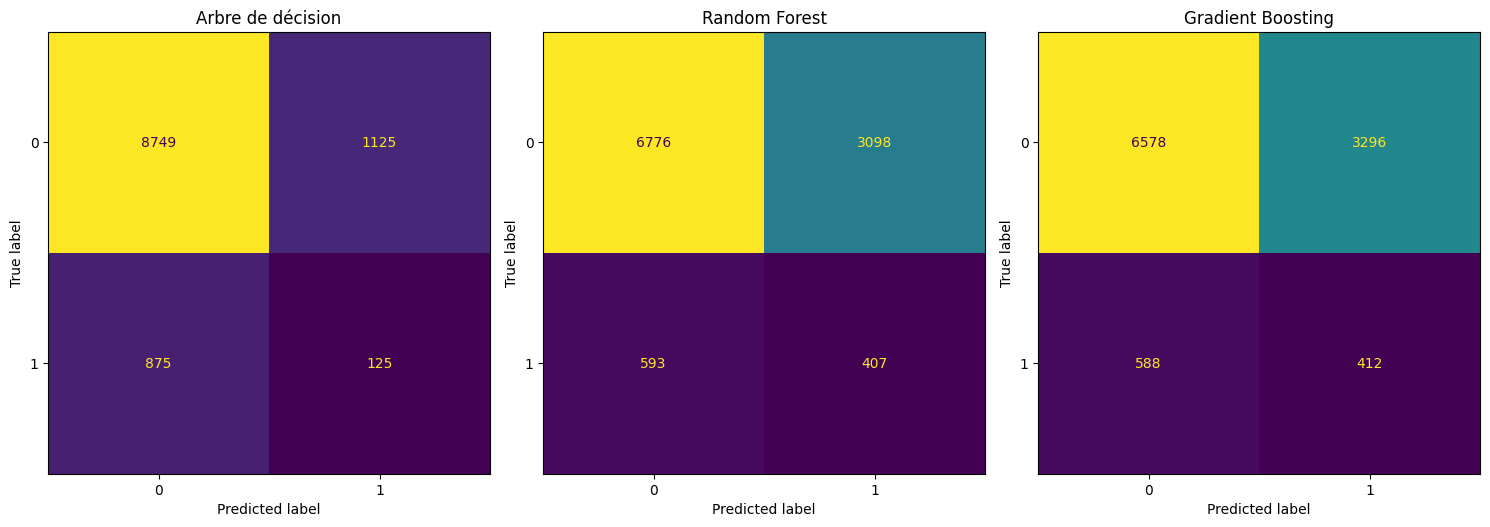

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay  # outil pour afficher une matrice de confusion en image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # crée 1 ligne de 3 graphiques côte à côte

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arbre, ax=axes[0], colorbar=False)
axes[0].set_title("Arbre de décision")  # titre du 1er graphique

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_foret, ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")  # titre du 2e graphique

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, ax=axes[2], colorbar=False)
axes[2].set_title("Gradient Boosting")  # titre du 3e graphique

plt.tight_layout()  # évite que les graphiques se chevauchent
plt.savefig("resultats/comparaison_matrices_confusion.png", dpi=150)  # sauvegarde l'image dans ton dossier resultats/
plt.show()  # affiche le graphique dans le notebook

In [66]:
#Ce projet met en évidence un arbitrage classique en apprentissage supervisé : optimiser le F1 
# favorise un compromis global, mais ne reflète pas nécessairement la priorité métier réelle (ici, 
# éviter les fausses accusations) — un ajustement du seuil de décision ou du scoring vers la précision 
# serait une piste d'amélioration.

### Courbe ROC et AUC (complément)

La courbe ROC teste **tous les seuils de décision**, pas seulement 50 %. L'AUC résume cela : 0,5 = hasard, 1 = parfait.

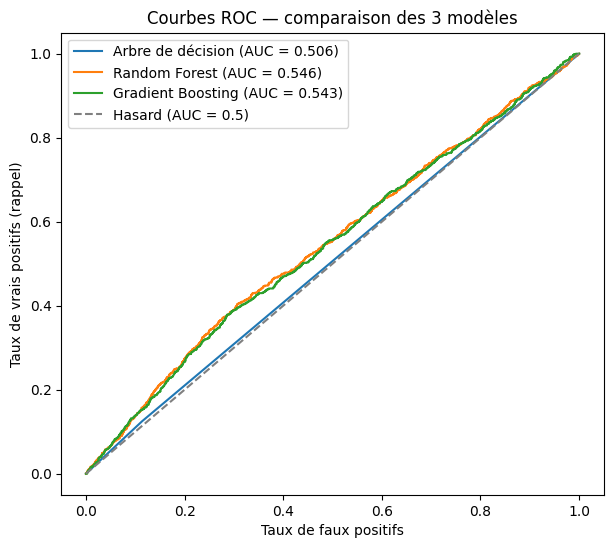

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score  # outils pour calculer la courbe ROC et le score AUC

plt.figure(figsize=(7, 6))

for nom, modele in [("Arbre de décision", grid_arbre), ("Random Forest", grid_foret), ("Gradient Boosting", grid_gb)]:
    proba = modele.predict_proba(X_test)[:, 1]  # probabilité prédite d'avoir un carton (classe 1), pas juste 0/1
    fpr, tpr, seuils = roc_curve(y_test, proba)  # calcule taux de faux positifs (fpr) et vrais positifs (tpr) à chaque seuil
    auc = roc_auc_score(y_test, proba)           # résume la courbe en un seul chiffre
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {auc:.3f})")  # trace la courbe de ce modèle

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard (AUC = 0.5)")  # ligne de référence : un modèle aléatoire
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbes ROC — comparaison des 3 modèles")
plt.legend()
plt.savefig("resultats/courbe_roc.png", dpi=150)  # sauvegarde pour ton dossier resultats/
plt.show()

In [68]:
# Interprétation de la courbe ROC / AUC :
# Les 3 AUC (0.506 / 0.546 / 0.543) sont très proches de 0.5 (= hasard pur).
# Même Random Forest et Gradient Boosting, qui avaient un meilleur F1, ne savent
# pas vraiment distinguer un joueur qui prendra un carton d'un joueur qui n'en
# prendra pas.
#
# Le F1 amélioré avec class_weight/sample_weight reflète surtout un déplacement
# du seuil de décision (le modèle devient plus "alarmiste"), pas une vraie
# meilleure capacité à discriminer les deux classes. L'AUC teste tous les seuils
# possibles et révèle que cette capacité reste faible.
#
# Conclusion : ça confirme ce qu'on avait vu avec la corrélation quasi nulle
# entre les variables et yellow_cards. Le comportement disciplinaire dépend
# probablement de facteurs non présents dans ce dataset (décision arbitrale,
# contexte instantané du match), plutôt que des statistiques de jeu mesurées ici.

## Partie 2 — Importance des variables & SHAP

On analyse le modèle retenu (Random Forest, meilleur F1).

### Importance native vs importance par permutation

L'importance native (Gini) place `jersey_number` en tête — ce qui n'a **aucun sens footballistique**. C'est un **biais connu** : cette mesure favorise les variables à forte cardinalité (beaucoup de valeurs distinctes → plus d'occasions de découpage). L'**importance par permutation**, plus fiable, confirme le biais : toutes les importances s'effondrent (`jersey_number` passe de 0,128 à 0,008). Conclusion : **aucune variable n'a d'effet marquant.**

In [69]:
import pandas as pd  # déjà importé, mais on en a besoin ici

importances = pd.Series(grid_foret.best_estimator_.feature_importances_, index=X_train.columns)
# récupère l'importance de chaque variable selon le meilleur modèle Random Forest trouvé,
# et l'associe au nom de sa colonne correspondante

importances.sort_values(ascending=False).head(15)
# trie du plus important au moins important, affiche les 15 premières

jersey_number               0.127808
creativity_score            0.074768
offensive_contribution      0.054990
defensive_contribution      0.051848
market_value_eur            0.034829
total_minutes_tournament    0.031532
position_Midfielder         0.027902
pass_accuracy               0.024227
consistency_score           0.024063
height_cm                   0.023848
clutch_performance_score    0.023432
position_Goalkeeper         0.022747
distance_covered_km         0.022217
defensive_actions           0.020520
red_cards                   0.020009
dtype: float64

In [70]:
from sklearn.inspection import permutation_importance  # méthode plus fiable, sans ce biais de cardinalité

resultat_perm = permutation_importance(grid_foret.best_estimator_, X_test, y_test, scoring="f1", n_repeats=10, random_state=42)
# mélange aléatoirement chaque colonne une par une, et regarde de combien le score F1 chute
# si une variable est vraiment importante, la mélanger doit faire chuter le score fortement

importances_perm = pd.Series(resultat_perm.importances_mean, index=X_test.columns)
importances_perm.sort_values(ascending=False).head(15)

jersey_number             0.007832
position_Goalkeeper       0.003666
defensive_contribution    0.001993
pass_accuracy             0.001916
height_cm                 0.001801
red_cards                 0.001253
position_Midfielder       0.001004
total_passes              0.000964
decelerations             0.000655
clearances                0.000621
defensive_actions         0.000546
market_value_eur          0.000423
recoveries                0.000353
shots                     0.000307
stamina_score             0.000286
dtype: float64

### SHAP — interprétation globale et individuelle

**Summary plot** (global) : `defensive_contribution` et `defensive_actions` donnent l'effet le plus cohérent (plus d'engagement défensif → plus de risque de carton). Mais l'échelle des valeurs SHAP (−0,04 à +0,03) reste très faible — le signal global est ténu.

**Waterfall plot** (un joueur) : on décompose une prédiction individuelle, du score moyen (0,5) au score final, variable par variable — bleu = pousse vers « pas de carton », rouge = vers « carton ».

In [71]:
import shap  # bibliothèque pour l'interprétabilité des modèles

explainer = shap.TreeExplainer(grid_foret.best_estimator_)  # crée un explicateur adapté aux modèles à base d'arbres
shap_values = explainer.shap_values(X_test)  # calcule la contribution de chaque variable pour chaque prédiction du test

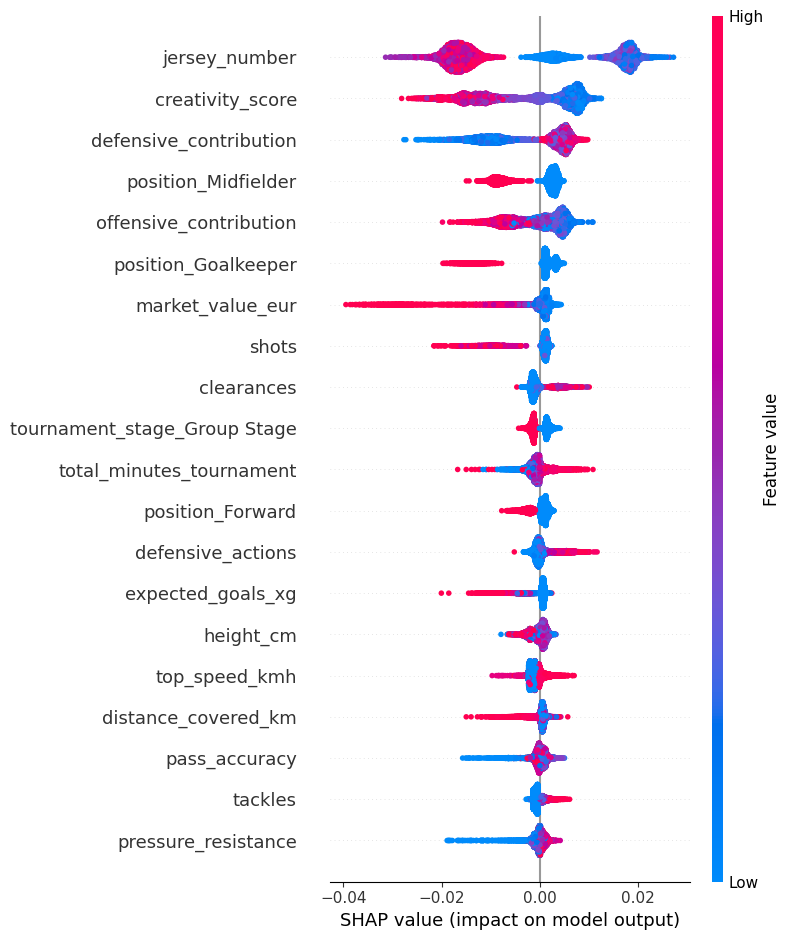

In [73]:
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
# show=False empêche l'affichage immédiat, pour qu'on puisse sauvegarder AVANT que la figure soit fermée

plt.savefig("resultats/shap_summary_plot.png", dpi=150, bbox_inches="tight")
# enregistre l'image dans ton dossier resultats/, bbox_inches="tight" évite de couper les textes sur les bords

plt.show()
# affiche le graphique dans le notebook

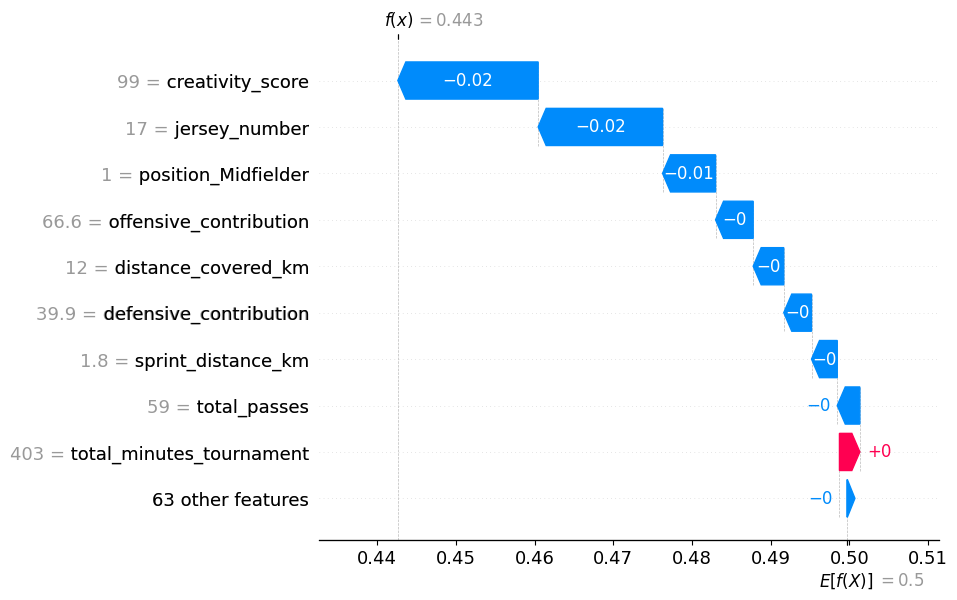

<Figure size 640x480 with 0 Axes>

In [74]:
idx = 0  # index du joueur à examiner dans X_test (on peut changer ce chiffre pour un autre joueur)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx, :, 1],              # les contributions SHAP pour ce joueur, classe "carton"
        base_values=explainer.expected_value[1],     # la prédiction moyenne de référence (avant d'ajouter les variables)
        data=X_test.iloc[idx],                       # les vraies valeurs des variables pour ce joueur
        feature_names=X_test.columns.tolist()        # les noms des colonnes
    )
)
plt.savefig("resultats/shap_waterfall_joueur0.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
# Interprétation du waterfall plot (joueur idx=0) :
# E[f(X)] = 0.5 -> prediction moyenne sur tout le dataset (point de depart)
# f(x) = 0.443 -> prediction finale pour CE joueur precis
#
# Bleu = pousse vers "PAS de carton" | Rouge = pousse vers "carton"
#
# creativity_score = 99 (tres eleve) -> -0.02, pousse vers "pas de carton"
#   (un joueur tres createur commet sans doute moins de fautes cyniques)
# jersey_number = 17                 -> -0.02, pousse vers "pas de carton"
#   (effet a relativiser : variable identifiee plus tot comme bruit/artefact)
# position_Midfielder = 1            -> -0.01, effet mineur vers "pas de carton"
# total_minutes_tournament = 403     -> +0, seul effet vers "carton", mais negligeable
# 63 autres variables                -> effets quasi nuls
#
# Conclusion : ce joueur a un risque de carton legerement INFERIEUR a la moyenne
# (0.443 vs 0.5), principalement grace a sa forte creativite de jeu.

## Partie 3 — Apprentissage non supervisé

Ici, `yellow_cards` **n'est pas utilisée** pour construire les groupes : elle ne sert qu'à interpréter les résultats *a posteriori* (usage « post-hoc » autorisé par les consignes).

### Standardisation

Contrairement aux arbres (insensibles à l'échelle), **PCA et KMeans sont très sensibles à l'échelle**. Sans standardisation, `market_value_eur` (des millions) écraserait `age` (des dizaines). On centre-réduit donc toutes les variables.

In [76]:
from sklearn.preprocessing import StandardScaler  # outil pour remettre toutes les variables à la même échelle

X_all = df_final.drop(columns=["yellow_cards"])  # toutes les variables, sans la cible (on ne l'utilise pas ici)

scaler = StandardScaler()  # crée l'outil de standardisation
X_scaled = scaler.fit_transform(X_all)  # transforme chaque variable pour qu'elle ait une moyenne de 0 et un écart-type de 1

In [77]:
X_scaled.shape

(54600, 72)

### PCA — réduction à 2 dimensions

Les 2 premières composantes ne conservent que **30,8 %** de l'information (21,9 % + 8,9 %) — attendu avec 72 variables peu corrélées. Malgré tout, une **structure visible** apparaît, en partie liée au **poste** : les gardiens forment un groupe nettement séparé (profil statistique très différent).

In [78]:
from sklearn.decomposition import PCA  # outil de réduction de dimension

pca = PCA(n_components=2)  # on réduit à 2 dimensions, pour pouvoir visualiser sur un graphique 2D
X_pca = pca.fit_transform(X_scaled)  # transforme les 72 colonnes en seulement 2 "super-colonnes"

pca.explained_variance_ratio_  # % d'information conservée par chacune des 2 nouvelles colonnes

array([0.21943072, 0.08880438])

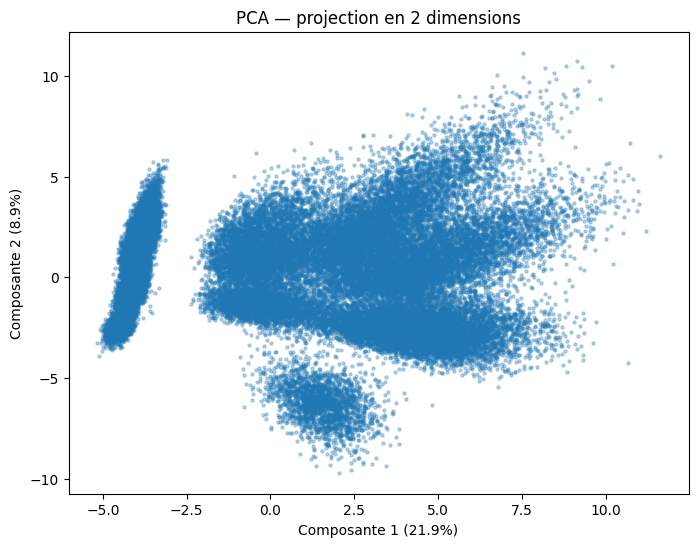

In [79]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.3)  # affiche chaque joueur comme un point selon ses 2 coordonnées PCA
plt.xlabel("Composante 1 (21.9%)")
plt.ylabel("Composante 2 (8.9%)")
plt.title("PCA — projection en 2 dimensions")
plt.savefig("resultats/pca_projection.png", dpi=150, bbox_inches="tight")
plt.show()

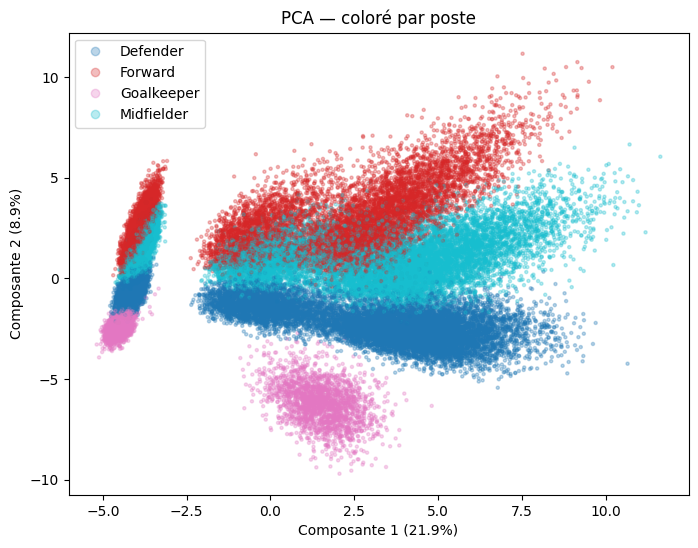

In [80]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["position"].astype("category").cat.codes, s=5, alpha=0.3, cmap="tab10")
# colore chaque point selon le poste du joueur (converti en code numérique juste pour la couleur)

plt.xlabel("Composante 1 (21.9%)")
plt.ylabel("Composante 2 (8.9%)")
plt.title("PCA — coloré par poste")
plt.legend(handles=scatter.legend_elements()[0], labels=df["position"].astype("category").cat.categories.tolist())
plt.savefig("resultats/pca_par_poste.png", dpi=150, bbox_inches="tight")
plt.show()

### Clustering — KMeans (k = 4)

On teste 4 groupes (comme les 4 postes). Le **silhouette score ≈ 0,135** est faible : les groupes se chevauchent et ne recouvrent pas exactement les postes réels (KMeans cherche des groupes ronds de taille comparable).

In [81]:
from sklearn.cluster import KMeans  # algorithme de clustering
from sklearn.metrics import silhouette_score  # mesure la qualité du clustering

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)  # cherche 4 groupes, n_init=10 essaie 10 initialisations différentes et garde la meilleure
clusters_kmeans = kmeans.fit_predict(X_scaled)  # assigne chaque joueur à un groupe (0, 1, 2 ou 3)

score = silhouette_score(X_scaled, clusters_kmeans, sample_size=2000, random_state=42)
# mesure la qualité des groupes (entre -1 et 1, proche de 1 = bons groupes bien séparés)
# sample_size=2000 : calcul sur un échantillon, sinon trop lent sur 54600 lignes
print("Silhouette :", score)

Silhouette : 0.13499807491945806


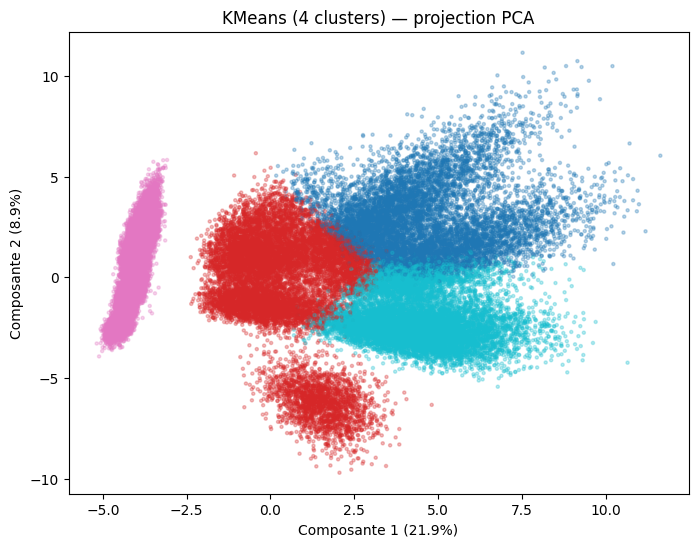

In [82]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, s=5, alpha=0.3, cmap="tab10")
# colore chaque point selon le groupe trouvé par KMeans (pas selon le poste, cette fois)

plt.xlabel("Composante 1 (21.9%)")
plt.ylabel("Composante 2 (8.9%)")
plt.title("KMeans (4 clusters) — projection PCA")
plt.savefig("resultats/kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

### Clustering — DBSCAN (par densité)

DBSCAN détecte les zones denses sans imposer de forme ronde. Appliqué sur les **72 dimensions**, tout devient « bruit » (malédiction de la dimension : les distances explosent). On l'applique donc sur la **projection PCA 2D**, avec `eps=0.8`. Résultat : **2 clusters nets** (≈ 31 500 et 23 000 lignes) + 27 points de bruit. Le cluster isolé est **enrichi en gardiens** (18,2 % contre 6,7 %), mais le **taux de cartons y est quasi identique** (9,9 % vs 9,6 %).

In [83]:
from sklearn.cluster import DBSCAN  # algorithme de clustering par densité

dbscan = DBSCAN(eps=1.5, min_samples=20)  # eps = distance max pour considérer 2 points comme voisins, min_samples = nombre min pour former un groupe dense
clusters_dbscan = dbscan.fit_predict(X_scaled)  # -1 = bruit (point isolé, dans aucun groupe), 0/1/2... = numéro du groupe

pd.Series(clusters_dbscan).value_counts()  # compte combien de points dans chaque groupe (et combien de bruit)

-1    54600
Name: count, dtype: int64

In [84]:
dbscan = DBSCAN(eps=0.8, min_samples=20)  # eps réduit car on travaille maintenant en 2D (échelle du graphique PCA)
clusters_dbscan = dbscan.fit_predict(X_pca)  # applique DBSCAN sur les 2 composantes PCA, pas sur les 72 colonnes

pd.Series(clusters_dbscan).value_counts()  # compte combien de points dans chaque groupe (et combien de bruit, -1)

 0    31531
 1    23042
-1       27
Name: count, dtype: int64

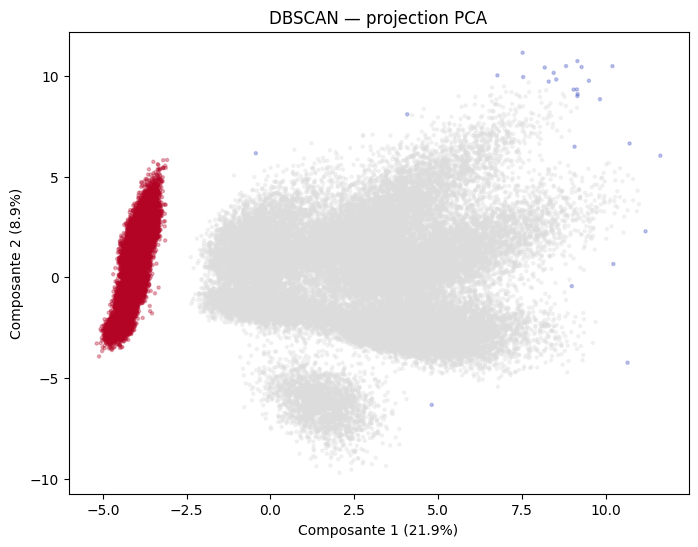

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, s=5, alpha=0.3, cmap="coolwarm")
# colore selon le groupe trouvé par DBSCAN (-1 = bruit, 0 et 1 = les 2 groupes)

plt.xlabel("Composante 1 (21.9%)")
plt.ylabel("Composante 2 (8.9%)")
plt.title("DBSCAN — projection PCA")
plt.savefig("resultats/dbscan_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [86]:
pd.crosstab(clusters_dbscan, df["position"])  # croise les clusters trouvés avec le vrai poste des joueurs

position,Defender,Forward,Goalkeeper,Midfielder
row_0,,,,
-1,1,19,1,6
0,11483,7681,2099,10268
1,7416,4900,4200,6526


In [87]:
df.groupby(clusters_dbscan)["yellow_cards"].mean()  # taux moyen de cartons dans chaque cluster

-1    0.074074
 0    0.099077
 1    0.096346
Name: yellow_cards, dtype: float64

In [88]:
# Interpretation du clustering (Partie 3) :
#
# KMeans (4 clusters) : silhouette = 0.135 -> faible, groupes tres chevauches.
# Ne retrouve pas exactement les postes (fusionne les gardiens avec un autre groupe).
#
# DBSCAN : 2 clusters nets (23042 et 31531 lignes) + 27 points de bruit.
# Cluster 1 (branche isolee a gauche) est sur-represente en gardiens (18.2% vs 6.7%
# dans l'autre cluster, alors que les gardiens ne sont que ~11.5% du dataset total).
# -> le clustering capture surtout un profil physique/poste, pas un comportement.
#
# Taux de yellow_cards par cluster : 9.9% (cluster 0) vs 9.6% (cluster 1) -> quasi identique.
# Aucun lien entre la structure trouvee par clustering et les cartons jaunes.
#
# Conclusion : cohérent avec toute l'analyse precedente (correlation nulle, AUC ~0.5,
# faible importance des variables) -> yellow_cards ne depend pas de la structure
# naturelle des donnees (poste/profil physique), mais probablement de facteurs
# non captures ici (decision arbitrale, contexte instantane du match).

## Conclusion générale

À travers **toutes** les analyses — corrélation quasi nulle, AUC ≈ 0,5, importances par permutation minuscules, valeurs SHAP faibles, clustering sans lien avec la cible — **aucune méthode ne parvient à prédire correctement les cartons jaunes** à partir des variables disponibles.

C'est une conclusion **cohérente et honnête** : le comportement disciplinaire dépend très probablement de facteurs **absents de ce dataset** (décision arbitrale, contexte instantané du match, tension du moment) plutôt que des statistiques de jeu mesurées ici.

Sur le plan méthodologique, le projet illustre en revanche plusieurs points clés : le piège de l'accuracy sur données déséquilibrées, le rééquilibrage des classes (`class_weight` / `sample_weight`), l'arbitrage précision / rappel, le biais de cardinalité des importances natives, et la différence de comportement entre KMeans et DBSCAN. **Un « mauvais » score prédictif accompagné d'une démarche rigoureuse reste un résultat valable.**